**Law of Large Numbers**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def coin_flip_experiment():
  # defining our two coins as lists
  coin1 = ['Heads', 'Tails']
  coin2 = ['Heads', 'Tails']

  # "flipping" both coins randomly
  coin1_result = np.random.choice(coin1)
  coin2_result = np.random.choice(coin2)

  # checking if both flips are heads
  if coin1_result == 'Heads' and coin2_result == 'Heads':
    return 1
  else:
    return 0

# how many times we run the experiment
num_trials = 1000
prop = []
flips = []
# keep track of the number of times heads pops up twice
two_heads_counter = 0

# perform the experiment five times
for flip in range(num_trials):
  # if both coins are heads add 1 to the counter
  two_heads_counter += coin_flip_experiment()
  # keep track of the proportion of two heads at each flip
  prop.append(two_heads_counter/(flip+1))
  # keep a list for number of flips
  flips.append(flip+1)

# plot all flips and proportion of two heads
plt.plot(flips, prop, label='Experimental Probability')
plt.xlabel('Number of Flips')
plt.ylabel('Proportion of Two Heads')

plt.hlines(0.25, 0, num_trials, colors='orange', label='True Probability')
plt.legend()

We are working in a call center, and we expect the average number of calls in our call center between 9am and 10am to be 15 calls. What is the probability that we would see exactly 15 calls in that time frame?

In [ ]:
import scipy.stats as stats

prob_15 = stats.poisson.pmf(30,15)
print(prob_15)

What is the probability we would get between 7 and 9 calls?

In [ ]:
prob_7_to_9 = stats.poisson.pmf(7,15) + stats.poisson.pmf(8,15) + stats.poisson.pmf(9,15)
print(prob_7_to_9)

Working at a call center where the average number of calls between 9am and 10am is 15 calls, what is the probability of observing more than 20 calls?

In [ ]:
prob_more_than_20 = 1 - stats.poisson.cdf(20, 15)
print(prob_more_than_20)

What is the probability of observing between 17 to 21 calls when the expected number of calls is 15?

In [ ]:
prob_17_to_21 = stats.poisson.cdf(21, 15) - stats.poisson.cdf(16, 15)
print(prob_17_to_21)

**Sampling Distributions**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

population = pd.read_csv("cod_population.csv")

population = population['Cod_Weight']

sample_size = 50
sample_means = []

for i in range(500):
  samp = np.random.choice(population, sample_size, replace = False)
  # calculate mean here
  this_sample_mean = np.mean(samp)
  # append here
  sample_means.append(this_sample_mean)

sns.histplot(sample_means,stat='density')
plt.title("Sampling Distribution of the Mean")
plt.xlabel("Weight (lbs)")
plt.show()

**Calculating Probabilities with CDF**

In [ ]:
import scipy.stats as stats
x = 75
mean = 60
std_dev = 40
samp_size = 10
standard_error = std_dev / (samp_size**.5)
stats.norm.cdf(x,mean,standard_error)

**ONE-SAMPLE T-TESTS IN SCIPY**

In [ ]:
#what is the mean of the order data?
import pandas as pd
import numpy as np

order = pd.read_csv("price.csv")
order_mean = np.mean(order)
print(order_mean)

In [ ]:
#what is the p-value?
from scipy.stats import ttest_1samp
tstat, pval = ttest_1samp(order,1000)
print(pval)

In [ ]:
# The values are normally distributed?
import matplotlib.pyplot as plt
plt.hist(order)
plt.show()

**SIMULATING A BINOMIAL TEST**

In [ ]:
import pandas as pd

monthly_report = pd.read_csv('monthly_report.csv')
monthly_report.head()

In [ ]:
#The number of people who visited the website
sample_size = len(monthly_report["purchase"])
print(sample_size)

In [ ]:
#The number of people who made a purchase on the website
num_purchased = len(monthly_report[monthly_report["purchase"] == "y"])
print(num_purchased)

In [ ]:
#Simulate 1 visitor to the website
one_visitor = np.random.choice(['y', 'n'], size=1, p=[0.1, 0.9])
print(one_visitor)

In [ ]:
#Sinmulate 500 visitor to the website
simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[0.1, 0.9])
print(simulated_monthly_visitors)

num_purchased = np.sum(simulated_monthly_visitors=="y")
print(num_purchased)

In [ ]:
#Simulating the Null Distribution

null_outcomes = []

for i in range(10000):
  simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[0.1, 0.9])

  num_purchased = np.sum(simulated_monthly_visitors == 'y')

  null_outcomes.append(num_purchased)

null_min = np.min(null_outcomes)
null_max = np.max(null_outcomes)
print(null_min)
print(null_max)

In [ ]:
#Inspecting the Null Distribution
import matplotlib.pyplot as plt

plt.hist(null_outcomes)
plt.axvline(41, color = 'r')
plt.show()

In [ ]:
#What is the 90% confidence level?
null_90CI = np.percentile(null_outcomes, [5,95])
print(null_90CI)

In [ ]:
#What is the p-value of hypothesis testing - One-Sided P-Value
#Null: the probability of a purchase was 10%
#Alternative: the probability of a purchase rate was LESS THAN 10%

null_outcomes = np.array(null_outcomes)
p_value = np.sum(null_outcomes <= 41)/len(null_outcomes)
print(p_value)

In [ ]:
#What is the p-value of hypothesis testing - Two-Sided P-Value
#Null: the probability of a purchase was 10%
#Alternative: the probability of a purchase rate was LESS THAN 10%
null_outcomes = np.array(null_outcomes)
p_value = np.sum((null_outcomes <= 41) | (null_outcomes >= 59))/len(null_outcomes)
print(p_value)

In [ ]:
#Run binomial test with Python Libraries
from scipy.stats import binom_test
p_value_2sided = binom_test(41,500,0.1)
print(p_value_2sided)

In [ ]:
#Setting the Type I Error Rate
import numpy as np
from scipy.stats import binom_test

false_positives = 0
sig_threshold = 0.05

for i in range(1000):
    sim_sample = np.random.choice(['correct', 'incorrect'], size=100, p=[0.7, 0.3])
    num_correct = np.sum(sim_sample == 'correct')
    p_val = binom_test(num_correct, 100, .7)
    if p_val < sig_threshold:
        false_positives += 1

# Print proportion of type I errors
print(false_positives/1000)

**INTRODUCTION TO LINEAR REGRESSION**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


students = pd.read_csv('test_data.csv')


y = 9.85 * students.hours_studied + 43


plt.scatter(students['hours_studied'],students['score'])

plt.plot(students.hours_studied, y)
plt.show()

In [ ]:
#Fit a linear regression model with OLS.from_formula()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

students = pd.read_csv('test_data.csv')
model = sm.OLS.from_formula('score~hours_studied', data = students)
results = model.fit()
print(results.params)

In [ ]:
#Using a Regression Model for Prediction
print(results.params)

pred_3hr = results.params[1]*3 + results.params[0]
print(pred_3hr)

newdata = {"hours_studied":[5]}
pred_5hr = results.predict(newdata)
print(pred_5hr)

In [ ]:
#calculate fitted value and residual

model = sm.OLS.from_formula('score ~ hours_studied', students)
results = model.fit()

fitted_values = results.predict(students["hours_studied"])
print(fitted_values.head())

residuals = students["score"] - fitted_values
print(residuals.head())

In [ ]:
#check Normality assumption and Homoscedasticity assumption

plt.hist(residuals)
plt.show()

plt.scatter(fitted_values, residuals)
plt.show()

In [ ]:
#Categorical Predictors

print(students.groupby('breakfast').mean().score)
plt.scatter(students['breakfast'],students['score'])
plt.plot([0,1], [61.66415094339621,73.7212765957447])
plt.show()

In [ ]:
#Categorical Predictors: Fit and Interpretation

mean_score_no_breakfast = np.mean(students.score[students.breakfast == 0])
mean_score_breakfast = np.mean(students.score[students.breakfast == 1])
print('Mean score (no breakfast): ', mean_score_no_breakfast)
print('Mean score (breakfast): ', mean_score_breakfast)


model = sm.OLS.from_formula('score ~ breakfast', students)
results = model.fit()
print(results.params)

print(mean_score_breakfast - mean_score_no_breakfast)

**EDA - Netflix data**

In [ ]:
#Inspect the first five rows, the rating variable is quantitative or categorical data?
import pandas as pd

movies = pd.read_csv("netflix_movies.csv", index_col=0)
movies.head()

In [ ]:
#Inspect the unique values of the country column, the country variable is quantitative or categorical data?
print(movies.country.unique())

In [ ]:
#Inspect the first five rows of the release_year, and identify whether this column is discrete or continuous.
movies.head()

In [ ]:
#Check the data types of all the variables in the movies data
print(movies.dtypes)

In [ ]:
#Fill in the missing values with 0 and change the cast_count variable to an integer of type int64
movies['cast_count'].fillna(0, inplace = True)
movies['cast_count'] = movies['cast_count'].astype("int64")
print(movies.dtypes)

In [ ]:
#change the other variable to string
movies['title'] = movies['title'].astype("string")
movies['type'] = movies['type'].astype("string")
movies['country'] = movies['country'].astype("string")
movies['rating'] = movies['rating'].astype("string")
print(movies.dtypes)

In [ ]:
#Change the data type of the rating variable to ordinal categorical
movies['rating'] = pd.Categorical(movies['rating'], ['NR', 'G', 'PG','PG-13','R'], ordered=True)
print(movies['rating'].unique())

In [ ]:
#Sorted the dataset by the logical order of the rating
movies.sort_values('rating')

In [ ]:
#One-Hot Encode the type variable
movies = pd.get_dummies(data=movies, columns=['type'])
print(movies.head())

**EDA - Basic summary statistics and visualizations**

In [ ]:
# Print the summary statistics for all columns
import pandas as pd

movies = pd.read_csv('movies.csv')
print(movies.head())
print(movies.describe(include='all'))

In [ ]:
#find the Central Tendency of the data
mean_budget = movies.production_budget.mean()
med_budget = movies.production_budget.median()
mode_budget = movies.production_budget.mode()
print(mean_budget)
print(med_budget)
print(mode_budget)

from scipy.stats import trim_mean
trmean_budget = trim_mean(movies.production_budget, proportiontocut=0.2)
print(trmean_budget)

In [ ]:
#find the Spread for Quantitative Data
range_budget = movies.production_budget.max() - movies.production_budget.min()
iqr_budget = movies.production_budget.quantile(0.75) - movies.production_budget.quantile(0.25)
var_budget = movies.production_budget.var()
std_budget = movies.production_budget.std()

print(range_budget)
print(iqr_budget)
print(var_budget)
print(std_budget)

In [ ]:
#Visualizing Quantitative Variables
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='production_budget', data=movies)
plt.show()

In [ ]:
sns.histplot(x='production_budget', data=movies)
plt.show()

In [ ]:
#Value Counts for Categorical Data
genre_counts = movies.genre.value_counts()
print(genre_counts)

In [ ]:
genre_props = movies.genre.value_counts(normalize=True)
print(genre_props)

In [ ]:
#Visualizing Categorical Variables

sns.countplot(x='genre', data=movies)
plt.show()

In [ ]:
movies.genre.value_counts().plot.pie()
plt.show()

**Associations: Quantitative variables and Categorical variables**

In [2]:
#separate out scores for students who live in urban and rural locations:
import pandas as pd
students = pd.read_csv('students.csv')
print(students.head())
scores_urban = students.G3[students.address == 'U']
scores_rural = students.G3[students.address == 'R']
print(scores_urban.head())
print(scores_rural.head())

  school address  absences     Mjob      Fjob  G3
0     GP       U         6  at_home   teacher   6
1     GP       U         4  at_home     other   6
2     GP       U        10  at_home     other  10
3     GP       U         2   health  services  15
4     GP       U         4    other     other  10
0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64
24     8
32    16
37    15
38    11
39    13
Name: G3, dtype: int64


In [3]:
#Mean and Median Differences
import numpy as np
scores_urban_mean = np.mean(scores_urban)
scores_rural_mean = np.mean(scores_rural)
mean_diff = scores_urban_mean-scores_rural_mean
print(mean_diff)

#calculate medians for each group:
scores_urban_median = np.median(scores_urban)
scores_rural_median = np.median(scores_rural)
median_diff = scores_urban_median-scores_rural_median
print(median_diff)

1.1629034646135619
1.0


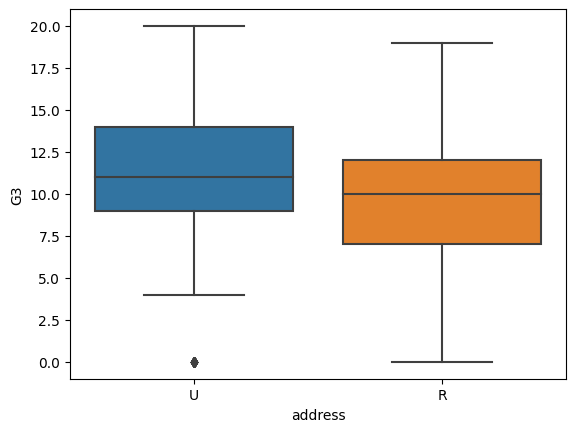

In [4]:
#Side-by-Side Box Plots
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data = students, x = 'address', y = 'G3')
plt.show()

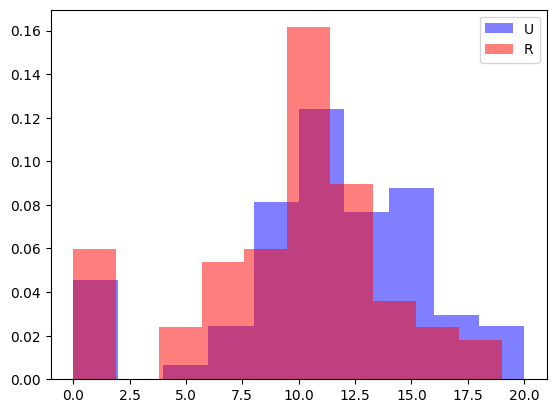

In [5]:
#Inspecting Overlapping Histograms
plt.hist(scores_urban , color="blue", label="U", density=True, alpha=0.5)
plt.hist(scores_rural , color="red", label="R", density=True, alpha=0.5)
plt.legend()
plt.show()

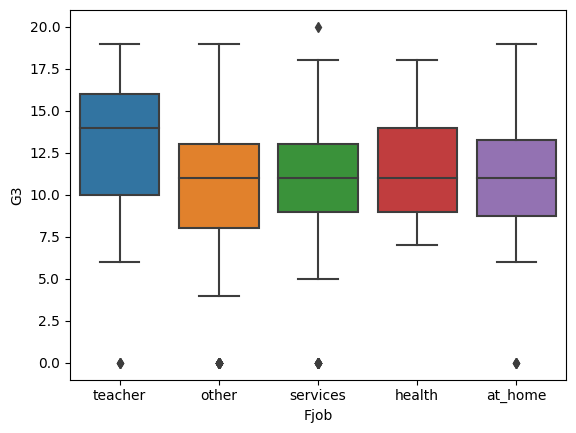

In [6]:
#Exploring Non-Binary Categorical Variables
sns.boxplot(data = students, x = 'Fjob', y = 'G3')
plt.show()

**Associations: Two Quantitative variables**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv('housing_sample.csv')
print(housing.head())

plt.scatter(x = housing.beds, y = housing.sqfeet)
plt.xlabel('Beds')
plt.ylabel('Square Feet')
plt.show()

In [ ]:
# calculate and print covariance matrix:
cov_mat_sqfeet_beds = np.cov(housing.beds, housing.sqfeet)
print(cov_mat_sqfeet_beds)

In [ ]:
# calculate Correlation bewteen two variables
correlation = housing['beds'].corr(housing['sqfeet'])
print(correlation)

In [ ]:
# calculate Correlation bewteen two variables with non-linear relationsip
sleep = pd.read_csv('sleep.csv')
plt.scatter(x = sleep.hours_sleep, y = sleep.performance)
plt.show()

corr_sleep_performance = sleep.hours_sleep.corr(sleep.performance)
print(corr_sleep_performance)

**Associations: Two Categorical variables**

In [ ]:
#Contingency Tables: Frequencies
import pandas as pd

npi = pd.read_csv("npi.csv")
special_authority_freq = pd.crosstab(npi.special, npi.authority)
print(special_authority_freq)

In [ ]:
#Contingency Tables: Proportions
special_authority_prop = pd.crosstab(npi.special, npi.authority)/len(npi)
print(special_authority_prop)

In [ ]:
#Calcualte Marginal Proportions
authority_marginals = special_authority_prop.sum(axis=0)
print(authority_marginals)

special_marginals = special_authority_prop.sum(axis=1)
print(special_marginals)

In [ ]:
#Expected Contingency Tables
from scipy.stats import chi2_contingency
chi2, pval, dof, expected = chi2_contingency(special_authority_freq)
print(np.round(expected))

In [ ]:
#The Chi-Square Statistic
from scipy.stats import chi2_contingency
chi2, pval, dof, expected = chi2_contingency(special_authority_freq)
print(chi2)